<a href="https://colab.research.google.com/github/princeprakash24/Customer-Behavior-Conversion-Analytics-for-E-Commerce-Platform/blob/main/Customer_Behavior_%26_Conversion_Analytics_for_E_Commerce_Platform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing libraries and Load dataset**

---



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/ecommerce_data.csv")

print(df.head())

   user_id signup_date  visit  view_product  add_to_cart  purchase group  \
0        1  2024-02-08      1             0            0         0     B   
1        2  2024-01-15      1             1            1         0     A   
2        3  2024-01-19      1             1            0         0     A   
3        4  2024-02-22      1             1            1         0     A   
4        5  2024-01-02      1             1            1         0     B   

  purchase_date  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4           NaN  


**Funnel Analysis**

In [12]:
funnel = {
"Visit": df['visit'].sum(),
"View Product": df['view_product'].sum(),
"Add to Cart": df['add_to_cart'].sum(),
"Purchase": df['purchase'].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=['Step','Users'])

print(funnel_df)

           Step  Users
0         Visit   1000
1  View Product    763
2   Add to Cart    347
3      Purchase    118


**Visualization**

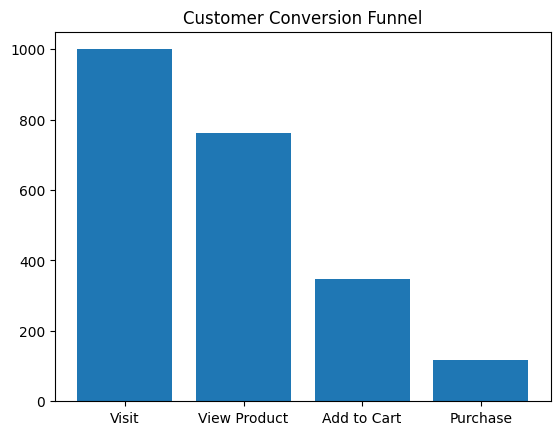

In [13]:
plt.figure()
plt.bar(funnel_df['Step'],funnel_df['Users'])
plt.title("Customer Conversion Funnel")
plt.show()

**Cohort Analysis**

In [14]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

df['signup_month'] = df['signup_date'].dt.to_period('M')
df['purchase_month'] = df['purchase_date'].dt.to_period('M')

**Create cohort table.**

In [15]:
cohort = df.groupby(['signup_month','purchase_month'])['user_id'].nunique()

print(cohort)

signup_month  purchase_month
2024-01       2024-01           43
              2024-02            8
2024-02       2024-02           55
              2024-03           12
Name: user_id, dtype: int64


**A/B Testing**

In [16]:
from scipy.stats import ttest_ind

groupA = df[df['group']=='A']['purchase']
groupB = df[df['group']=='B']['purchase']

t_stat,p_value = ttest_ind(groupA,groupB)

print("P-value:",p_value)

P-value: 0.07031098555147901


**Visualization of A/B Test**

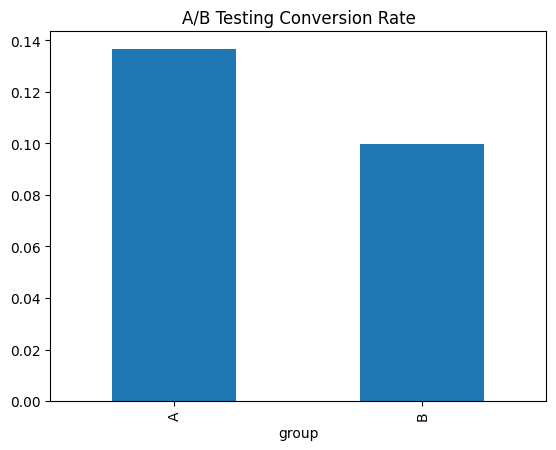

In [17]:
conversion = df.groupby('group')['purchase'].mean()

plt.figure()
conversion.plot(kind='bar')
plt.title("A/B Testing Conversion Rate")
plt.show()